In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import subprocess
from scipy.stats import chisquare
import os
import glob

# import scipy.stats as stats

In [2]:
%load_ext autoreload

%autoreload 2
import pandas as pd
import numpy as np
%aimport Variant_analysis_helper_functions


#import protfasta
import os

In [3]:
import os

def run_full_pipeline(variants_filename):
    """
    Runs the full mutation pipeline for a given variants file.
    Checks directories and prints warnings if they exist.
    """
    variants_folder = "/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/"

    # Run scripts sequentially
    print("\nRunning get_full_mutations.py ...")
    os.system(f"python3 ../scripts/get_full_mutations.py --variants_filename {variants_filename} --variants_folder {variants_folder} --sort_TFs true --sort_variants true")
    
    print("\nRunning classify_mutations.py ...")
    os.system(f"python3 ../scripts/classify_mutations.py --variants_filename {variants_filename}")
    
    print("\nRunning get_mutations_domains_snv_classified.py ...")
    os.system(f"python3 ../scripts/get_mutations_domains_snv_classified.py --domain none --variants_filename {variants_filename}")



In [4]:
run_full_pipeline("gnomad.bed")


Running get_full_mutations.py ...
Sorting TF bed files.


100%|██████████| 1561/1561 [00:05<00:00, 310.03it/s]



Sorting variants. at /Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/gnomad.bed


/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/sorted/gnomad.bed
Starting intersecting CDS bed files and variants.


Intersecting:  71%|███████   | 1106/1561 [00:04<00:02, 205.09it/s]

Skipping directory ../outputs/mutations/cds_bed_format/sorted


...

Classifying:  13%|█▎        | 210/1560 [00:00<00:00, 2093.51it/s]

 does not have an ENST code


Classifying:  68%|██████▊   | 1053/1560 [00:01<00:00, 857.20it/s]

sorted does not have an ENST code


Classifying: 100%|██████████| 1560/1560 [00:01<00:00, 783.89it/s]


In [5]:
output = Variant_analysis_helper_functions.return_results(-1, 1, 
                                                       domain_types = ["AD", "DBD", "IDR"], 
                                                       print_output = False,
                                                      variant_filename = "gnomad")
output

Processing ENST codes: 100%|██████████| 45/45 [00:03<00:00, 12.33it/s]


,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,IDR_cds_length,IDR_missense,IDR_missense_prop,ADvsDBD_fisher_exact_p_vals,ADvsIDR_fisher_exact_p_vals,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,822,0.381616,582,219,0.376289,162,51,0.314815,1116,441,0.395161,1.661090e-01,4.630506e-01,7.646939e-01
1,ARX,Q96QS3,1689,413,0.244523,273,59,0.216117,171,11,0.064327,1512,400,0.264550,1.324820e-05,9.802168e-02,2.492065e-01
2,CASZ1,Q86V15,5280,2362,0.447348,465,234,0.503226,825,256,0.310303,3444,1710,0.496516,1.187727e-11,8.049673e-01,1.268770e-02
3,CC2D1A,Q6P1N0,2856,1257,0.440126,117,42,0.358974,2853,1257,0.440589,1293,603,0.466357,8.721389e-02,2.606401e-02,8.655500e-02
4,CAMTA2,O94983,3609,1457,0.403713,882,365,0.413832,339,74,0.218289,1941,854,0.439979,8.086176e-11,2.038530e-01,5.021855e-01
5,EBF3,Q9H4W6,1791,559,0.312116,240,58,0.241667,693,171,0.246753,633,259,0.409163,9.307171e-01,3.153245e-06,1.094639e-02
6,EGR3,Q06889,1164,349,0.299828,606,219,0.361386,213,21,0.098592,909,325,0.357536,1.610672e-14,9.129598e-01,2.032090e-06
7,ESR2,Q92731,1593,765,0.480226,1035,481,0.464734,210,87,0.414286,597,301,0.504188,1.966318e-01,1.357564e-01,9.292789e-02
8,GLIS1,Q8NBF1,1863,899,0.482555,522,247,0.473180,381,149,0.391076,1323,664,0.501890,1.461141e-02,2.778534e-01,6.422755e-01
9,ERG,P11308,1440,457,0.317361,573,196,0.342059,240,32,0.133333,912,336,0.368421,4.535505e-10,3.172031e-01,1.055774e-01


In [6]:
print("")
print("AD vs DBD significant:")
AD_vs_DBD_sig = Variant_analysis_helper_functions.return_bh_sig(output, "ADvsDBD_fisher_exact_p_vals", 0.1)
AD_vs_DBD_sig["AD_vs_DBD_sig"] = True
display(AD_vs_DBD_sig)

print("\nAD vs IDR significant:")
AD_vs_IDR_sig = Variant_analysis_helper_functions.return_bh_sig(output, "ADvsIDR_fisher_exact_p_vals", 0.1)
AD_vs_IDR_sig["AD_vs_IDR_sig"] = True
display(AD_vs_IDR_sig)

print("\nAD vs IDR significant:")
AD_vs_TF_sig = Variant_analysis_helper_functions.return_bh_sig(output, "ADvsTF_fisher_exact_p_vals", 0.1)
AD_vs_TF_sig["AD_vs_TF_sig"] = True
display(AD_vs_TF_sig)

merged_summary_results_ = (
    AD_vs_DBD_sig[["gene-symbol", "AD_vs_DBD_sig"]]
    .merge(
        AD_vs_IDR_sig[["gene-symbol", "AD_vs_IDR_sig"]],
        on="gene-symbol",
        how="outer"
    )
    .merge(
        AD_vs_TF_sig[["gene-symbol", "AD_vs_TF_sig"]],
        on="gene-symbol",
        how="outer"
    )
    .fillna(False)
)

merged_summary_results_


AD vs DBD significant:


/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_76668/2441517596.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AD_vs_DBD_sig["AD_vs_DBD_sig"] = True


,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,IDR_cds_length,IDR_missense,IDR_missense_prop,ADvsDBD_fisher_exact_p_vals,ADvsIDR_fisher_exact_p_vals,ADvsTF_fisher_exact_p_vals,AD_vs_DBD_sig
1,ARX,Q96QS3,1689,413,0.244523,273,59,0.216117,171,11,0.064327,1512,400,0.264550,1.324820e-05,9.802168e-02,2.492065e-01,True
2,CASZ1,Q86V15,5280,2362,0.447348,465,234,0.503226,825,256,0.310303,3444,1710,0.496516,1.187727e-11,8.049673e-01,1.268770e-02,True
4,CAMTA2,O94983,3609,1457,0.403713,882,365,0.413832,339,74,0.218289,1941,854,0.439979,8.086176e-11,2.038530e-01,5.021855e-01,True
6,EGR3,Q06889,1164,349,0.299828,606,219,0.361386,213,21,0.098592,909,325,0.357536,1.610672e-14,9.129598e-01,2.032090e-06,True
8,GLIS1,Q8NBF1,1863,899,0.482555,522,247,0.473180,381,149,0.391076,1323,664,0.501890,1.461141e-02,2.778534e-01,6.422755e-01,True
9,ERG,P11308,1440,457,0.317361,573,196,0.342059,240,32,0.133333,912,336,0.368421,4.535505e-10,3.172031e-01,1.055774e-01,True
10,HIVEP3,Q5T1R4,7221,979,0.135577,2592,325,0.125386,282,17,0.060284,6804,948,0.139330,9.118288e-04,7.952627e-02,6.238854e-02,True
11,IKZF1,Q13422,1560,534,0.342308,246,113,0.459350,279,81,0.290323,909,316,0.347635,6.712217e-05,1.746244e-03,3.847694e-05,True
12,KDM5B,Q9UGL1,4635,1962,0.423301,270,119,0.440741,255,90,0.352941,1185,512,0.432068,4.084754e-02,8.383015e-01,5.681137e-01,True
14,KLF7,O75840,909,242,0.266227,300,88,0.293333,219,32,0.146119,657,208,0.316591,8.766876e-05,4.979004e-01,2.022331e-01,True



AD vs IDR significant:


/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_76668/2441517596.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AD_vs_IDR_sig["AD_vs_IDR_sig"] = True


...


AD vs IDR significant:


/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_76668/2441517596.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AD_vs_TF_sig["AD_vs_TF_sig"] = True


,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,IDR_cds_length,IDR_missense,IDR_missense_prop,ADvsDBD_fisher_exact_p_vals,ADvsIDR_fisher_exact_p_vals,ADvsTF_fisher_exact_p_vals,AD_vs_TF_sig
2,CASZ1,Q86V15,5280,2362,0.447348,465,234,0.503226,825,256,0.310303,3444,1710,0.496516,1.187727e-11,8.049673e-01,1.268770e-02,True
5,EBF3,Q9H4W6,1791,559,0.312116,240,58,0.241667,693,171,0.246753,633,259,0.409163,9.307171e-01,3.153245e-06,1.094639e-02,True
6,EGR3,Q06889,1164,349,0.299828,606,219,0.361386,213,21,0.098592,909,325,0.357536,1.610672e-14,9.129598e-01,2.032090e-06,True
11,IKZF1,Q13422,1560,534,0.342308,246,113,0.459350,279,81,0.290323,909,316,0.347635,6.712217e-05,1.746244e-03,3.847694e-05,True
16,MEF2C,Q06413,1422,298,0.209564,1161,279,0.240310,144,9,0.062500,1179,282,0.239186,1.037996e-07,9.614035e-01,8.052584e-11,True
17,MEIS2,O14770,1434,463,0.322873,414,186,0.449275,174,15,0.086207,918,382,0.416122,1.918968e-19,2.813159e-01,1.621300e-10,True
18,MSX2,P35548,804,371,0.461443,102,37,0.362745,171,56,0.327485,609,310,0.509031,5.982238e-01,7.299756e-03,3.384230e-02,True
25,NR1D1,P20393,1845,758,0.410840,834,291,0.348921,213,56,0.262911,1017,427,0.419862,1.801955e-02,1.844308e-03,9.555233e-07,True
26,NR4A2,P43354,1797,656,0.365053,318,90,0.283019,210,22,0.104762,885,391,0.441808,4.684685e-07,5.333514e-07,8.248046e-04,True
28,OTX1,P32242,1065,438,0.411268,549,244,0.444444,171,47,0.274854,903,396,0.438538,8.061512e-05,8.276532e-01,2.494050e-02,True


/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_76668/2441517596.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,gene-symbol,AD_vs_DBD_sig,AD_vs_IDR_sig,AD_vs_TF_sig
0,ARX,True,False,False
1,CAMTA2,True,False,False
2,CASZ1,True,False,True
3,CC2D1A,False,True,False
4,EBF3,False,True,True
5,EGR3,True,False,True
6,ERG,True,False,False
7,GLIS1,True,False,False
8,HIVEP3,True,False,False
9,IKZF1,True,True,True


In [9]:
def plot_comparison(output, ax=None, domains_to_plot=None, legend=True):
    """
    Plot missense SNP frequencies for selected domains using Seaborn colorblind palette.
    
    Parameters:
    - output: DataFrame with columns like 'AD_missense_prop', 'DBD_missense_prop', etc.
    - ax: matplotlib axes object. If None, a new figure and axes are created.
    - domains_to_plot: list of domain names to plot. Options: 'AD', 'DBD', 'IDR_outside_AD', 'TF_outside_AD'.
                       Default: all of them.
    """
    sns.set_context('poster')
    palette = sns.color_palette("colorblind")

    # Fixed mapping of domain to palette index
    domain_colors = {
        "TF_outside_AD": palette[0],
        "AD": palette[1],
        "DBD": palette[2],
        "IDR_outside_AD": palette[3]
    }

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # Compute TF outside AD if needed
    rest_of_TF_prop = (output["TF_missense"] - output["AD_missense"]) \
                      / (output["TF_cds_length"] - output["AD_cds_length"])

    # Default domains
    if domains_to_plot is None:
        domains_to_plot = ["TF_outside_AD", "AD", "DBD", "IDR_outside_AD"]

    for domain in domains_to_plot:
        color = domain_colors.get(domain)
        if domain == "TF_outside_AD":
            sns.kdeplot(rest_of_TF_prop, label="TF outside AD", color=color, ax=ax)
        elif domain == "AD":
            sns.kdeplot(output["AD_missense_prop"], label="AD", color=color, ax=ax)
        elif domain == "DBD":
            sns.kdeplot(output["DBD_missense_prop"], label="DBD", color=color, ax=ax)
        elif domain == "IDR_outside_AD":
            sns.kdeplot(output["IDR_missense_prop"], label="IDR outside AD", color=color, ax=ax)
        else:
            raise ValueError(f"Unknown domain: {domain}")

    #ax.set_xlabel("Missense SNP Frequency")
    if legend:
        ax.legend(bbox_to_anchor = (1,1))
    sns.despine(ax=ax)
    
    return ax

Text(0.5, 1.0, 'SFARI TFs')

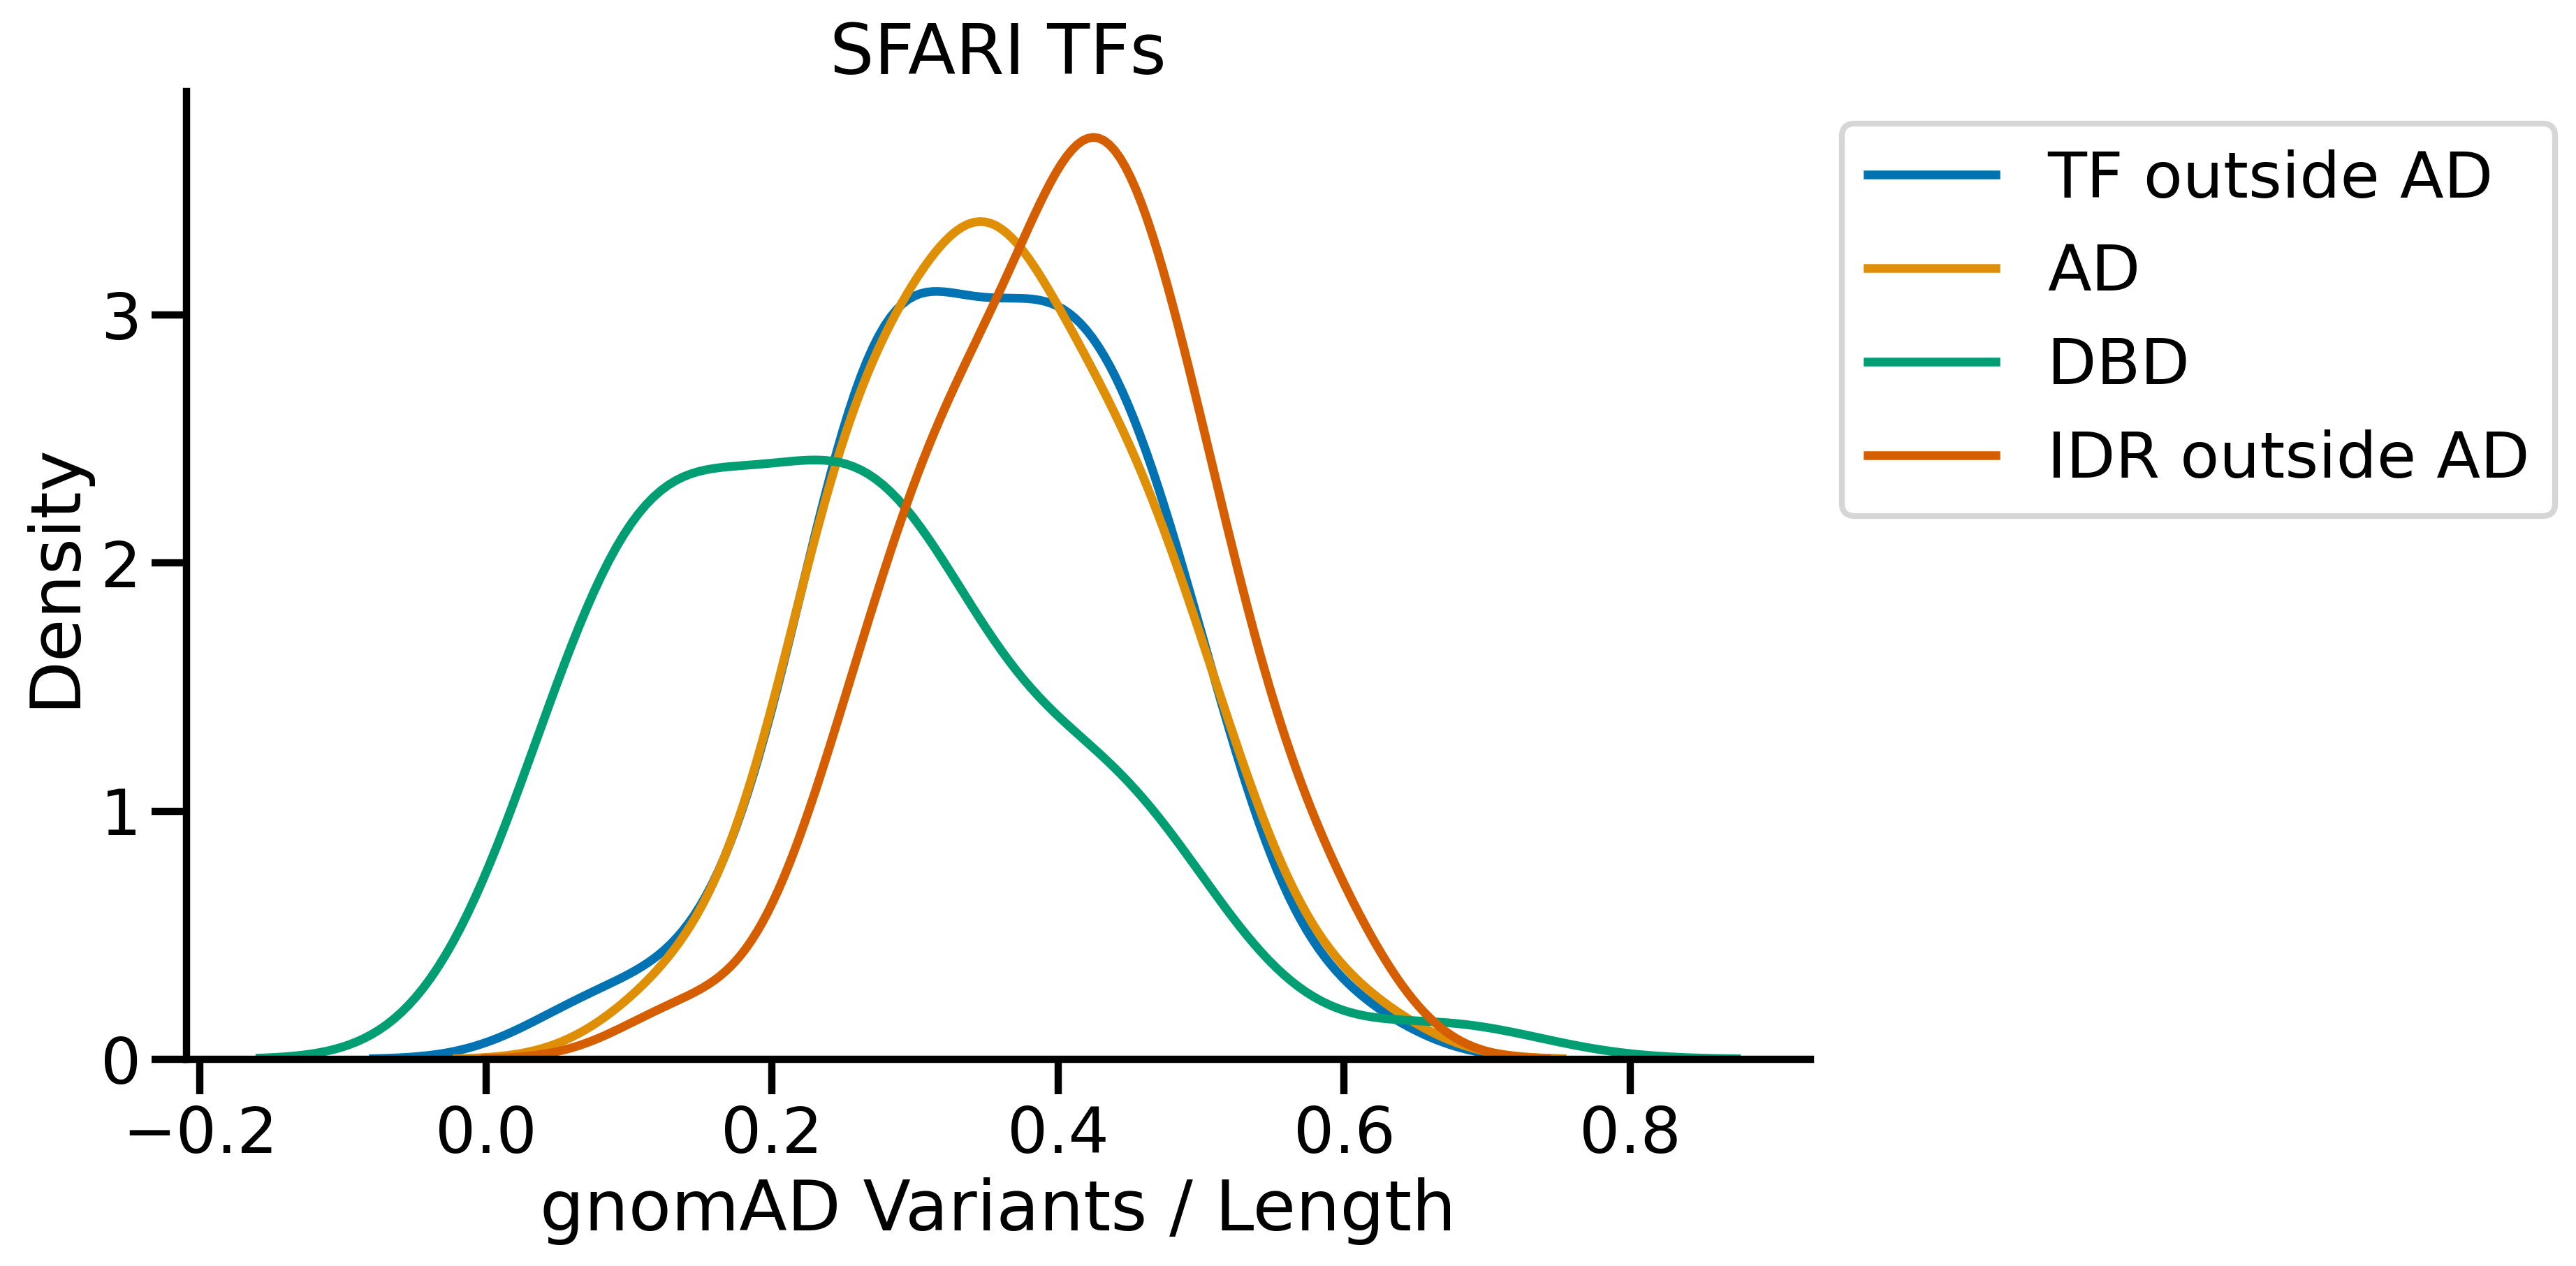

In [14]:
plot_comparison(output)
plt.xlabel("gnomAD Variants / Length")
plt.title("SFARI TFs")

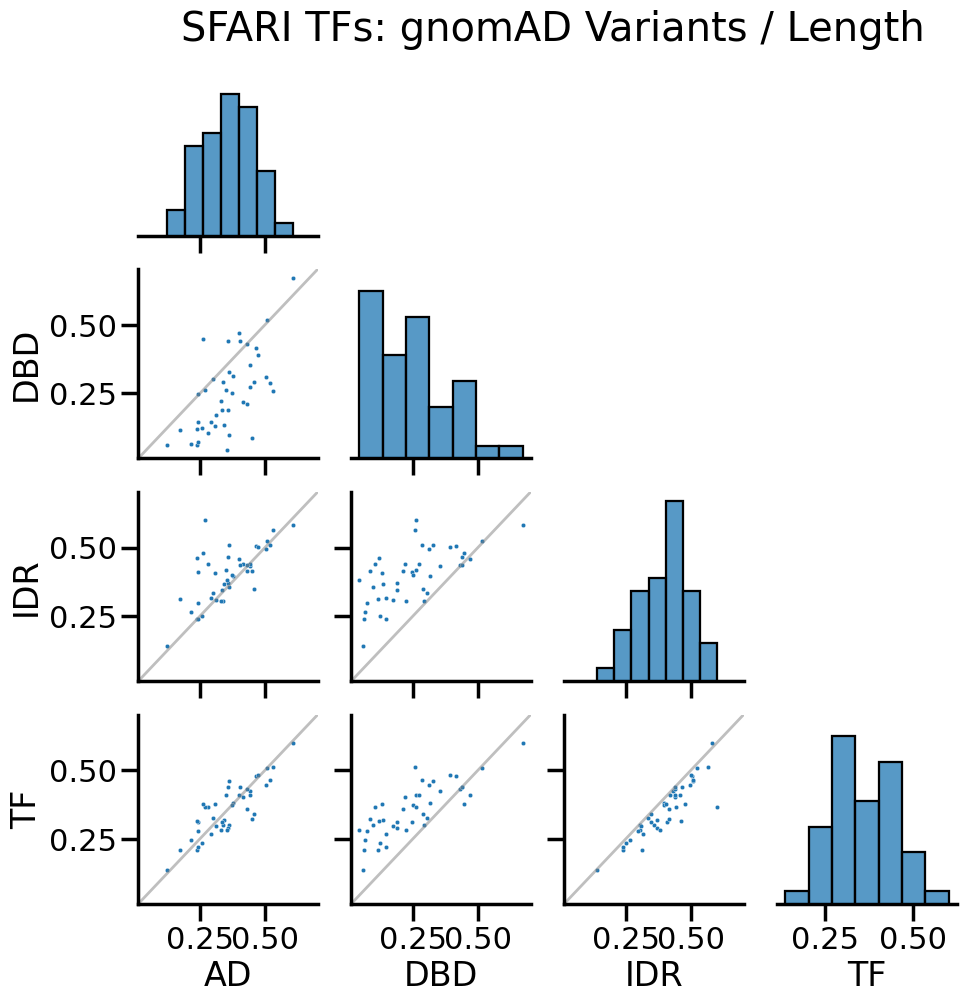

In [ ]:
g = sns.pairplot(
    output[[ "AD_missense_prop", "DBD_missense_prop", "IDR_missense_prop", "TF_missense_prop"]].rename(
        columns={
            "AD_missense_prop": "AD",
            "DBD_missense_prop": "DBD",
            "IDR_missense_prop": "IDR",
            "TF_missense_prop": "TF"
        }
    ),
    corner=True,
    plot_kws={"s": 10}
)
g.fig.suptitle("SFARI TFs: gnomAD Variants / Length", y = 1.01, x = 0.57)

# Add y=x line to each scatter in the lower triangle
for i in range(1, g.axes.shape[0]):
    for j in range(i):
        ax = g.axes[i, j]
        if ax is not None:
            lims = [
                min(ax.get_xlim()[0], ax.get_ylim()[0]),
                max(ax.get_xlim()[1], ax.get_ylim()[1])
            ]
            ax.plot(lims, lims, '-', color='gray', linewidth=2, alpha = 0.5)
            ax.set_xlim(lims)
            ax.set_ylim(lims)

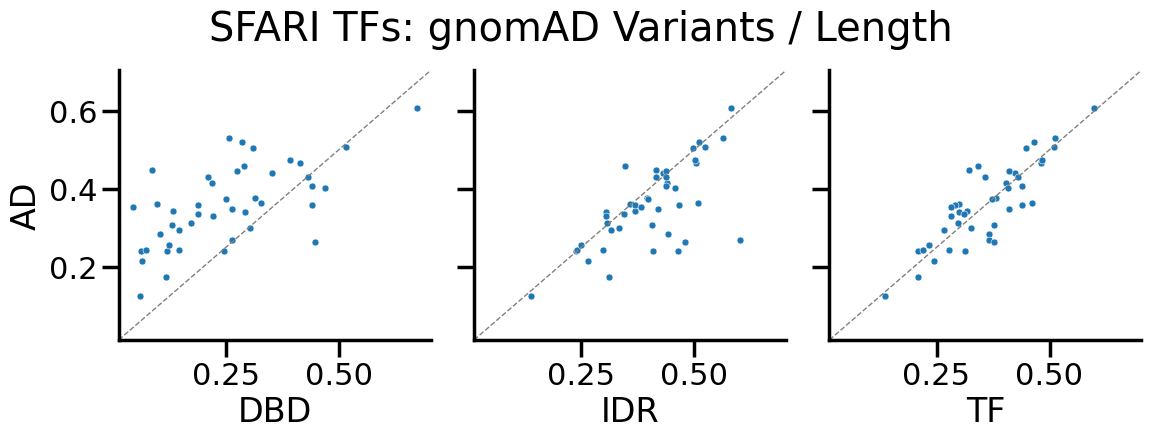

In [65]:



g = sns.pairplot(
    output.rename(
        columns={
            "AD_missense_prop": "AD",
            "DBD_missense_prop": "DBD",
            "IDR_missense_prop": "IDR",
            "TF_missense_prop": "TF"
        }
    ),
    x_vars = ["DBD", "IDR", "TF"],
    y_vars = "AD",
    plot_kws={"s": 25}, height = 4
)

# Add y=x line to each subplot
for ax in g.axes.flat:
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, '--', color='gray', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

g.fig.suptitle("SFARI TFs: gnomAD Variants / Length", y = 1.1, x = 0.5)
g.savefig("../../output/gnomad_enrichment_analysis.png", dpi = 300)